# Anime Face Generation: VAE + DDPM from scratch

Run each stage as a script (`!python x.py`), same commands you'd use in a terminal. No PyTorch Lightning - plain PyTorch training loops so everything is easy to read/debug.

**Runtime:** GPU (T4). In Colab: `Runtime > Change runtime type > T4 GPU`. On Kaggle: enable GPU T4 x2 in the notebook settings sidebar.

## 1. Setup: clone/upload project + install deps

In [1]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.0 MB/s eta 0:00:00


## 2. Kaggle API token

`data.py` uses `kagglehub` to download the dataset, which needs a Kaggle API token.

- **On Kaggle notebooks**: already configured, skip this cell.
- **On Colab**: upload your `kaggle.json` (from https://www.kaggle.com/settings -> API -> Create New Token) using the file upload cell below, or set the two env vars directly.

In [2]:
import os

# Option A: upload kaggle.json via Colab's file picker, then run this cell
# from google.colab import files
# uploaded = files.upload()  # select kaggle.json
# os.makedirs('/root/.kaggle', exist_ok=True)
# !mv kaggle.json /root/.kaggle/kaggle.json
# !chmod 600 /root/.kaggle/kaggle.json

# Option B: set credentials directly (replace with your own)
# os.environ['KAGGLE_USERNAME'] = 'your_username'
# os.environ['KAGGLE_KEY'] = 'your_key'


## 3. Check GPU

In [3]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))


CUDA available: True
Device: Tesla T4


## 4. Download + preprocess data

Downloads the anime face dataset (~63.6k images) via `kagglehub`, resizes to 64x64, and splits into `data/train/all/` and `data/test/all/`. Only needs to run once (re-run is a no-op if `data/train` is already populated).

In [4]:
!python data.py

Using Colab cache for faster access to the 'animefacedataset' dataset.
Path to dataset files: /kaggle/input/animefacedataset
Found 63565 total images in /kaggle/input/animefacedataset/images
Resizing + saving 61658 train / 1907 test images at 64x64 ...
resize[train]: 100% 61658/61658 [04:26<00:00, 231.25it/s]
resize[test]: 100% 1907/1907 [00:07<00:00, 247.19it/s]
Done.
  train dir: /content/data/train  (61658 images)
  test dir:  /content/data/test  (1907 images)


## 5. Train the VAE

Watch both `recon` and `kl` loss terms printed every log step / epoch average - see the README for what healthy vs. unhealthy curves look like. Checkpoints save every epoch to `checkpoints/vae.pt` (resumable via `--resume checkpoints/vae.pt` if your session gets cut off).

In [7]:
!python train_vae.py

Device: cuda
Train images: 61658 | batches/epoch: 240
VAE params: 11,815,555
epoch 0 step 0/240 loss=0.6929 recon=0.6796 kl=0.1332
epoch 0 step 100/240 loss=0.1605 recon=0.1439 kl=0.1667
epoch 0 step 200/240 loss=0.1406 recon=0.1200 kl=0.2065
epoch 0 DONE | avg_loss=0.1832 avg_recon=0.1645 avg_kl=0.1870 time=41.6s
[checkpoint] saved -> /content/checkpoints/vae.pt
[checkpoint] saved -> /content/checkpoints/vae_best.pt
epoch 1 step 0/240 loss=0.1383 recon=0.1177 kl=0.2063
epoch 1 step 100/240 loss=0.1263 recon=0.1054 kl=0.2097
epoch 1 step 200/240 loss=0.1225 recon=0.1016 kl=0.2089
epoch 1 DONE | avg_loss=0.1266 avg_recon=0.1058 avg_kl=0.2078 time=41.4s
[checkpoint] saved -> /content/checkpoints/vae.pt
[checkpoint] saved -> /content/checkpoints/vae_best.pt
epoch 2 step 0/240 loss=0.1192 recon=0.0987 kl=0.2040
epoch 2 step 100/240 loss=0.1174 recon=0.0963 kl=0.2109
epoch 2 step 200/240 loss=0.1169 recon=0.0953 kl=0.2156
epoch 2 DONE | avg_loss=0.1165 avg_recon=0.0952 avg_kl=0.2132 time=42

### Preview VAE samples/reconstructions so far

samples/vae/epoch_019.png


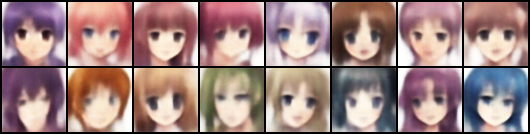

In [11]:
from PIL import Image
import glob

latest = sorted(glob.glob('samples/vae/epoch_*.png'))[-1]
print(latest)
Image.open(latest)


## 6. Evaluate the VAE

Generates a preview grid + a latent interpolation, and dumps `--num_samples` generated images to `samples/vae_eval/` for FID/IS scoring later. Lower `--num_samples` here if you're short on time/quota.

In [33]:
!python eval_vae.py --num_samples 100

[checkpoint] loaded <- /content/checkpoints/vae.pt
Loaded VAE from /content/checkpoints/vae.pt
Saved preview grid to /content/samples/vae_eval/preview_grid.png
generating VAE samples: 100% 100/100 [00:00<00:00, 630.50it/s]
Saved 100 generated images to /content/samples/vae_eval


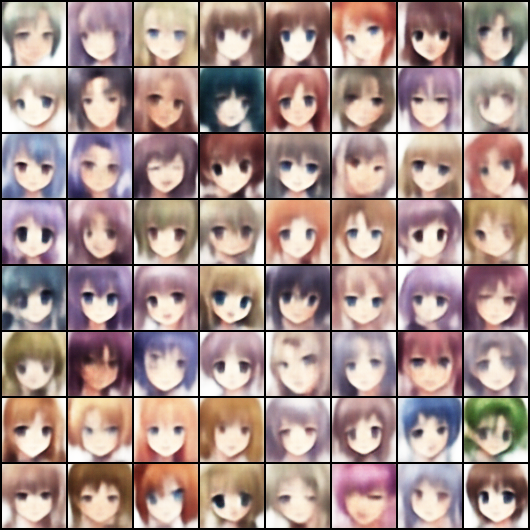

In [13]:
from PIL import Image
Image.open('samples/vae_eval/preview_grid.png')


## 7. Train the DDPM

Judge convergence by the **epoch average** `avg_mse_loss`, not individual steps (those are noisy since each step samples a random diffusion timestep). See the README for expected loss ranges. Checkpoints (including EMA weights, used for sampling) save every epoch to `checkpoints/ddpm.pt` and are resumable the same way as the VAE.

In [19]:
!python train_ddpm.py

Device: cuda
Physical batch_size=32 x grad_accum_steps=2 -> effective batch_size=64
Train images: 61658 | micro-batches/epoch: 1926 | optimizer steps/epoch: 963
UNet params: 26,623,363
epoch 0 step 0/1926 mse_loss=1.1268
epoch 0 step 100/1926 mse_loss=0.1139
epoch 0 step 200/1926 mse_loss=0.0949
epoch 0 step 300/1926 mse_loss=0.0443
epoch 0 step 400/1926 mse_loss=0.0381
epoch 0 step 500/1926 mse_loss=0.0568
epoch 0 step 600/1926 mse_loss=0.0709
epoch 0 step 700/1926 mse_loss=0.0659
epoch 0 step 800/1926 mse_loss=0.0634
epoch 0 step 900/1926 mse_loss=0.0324
epoch 0 step 1000/1926 mse_loss=0.0470
epoch 0 step 1100/1926 mse_loss=0.0149
epoch 0 step 1200/1926 mse_loss=0.0217
epoch 0 step 1300/1926 mse_loss=0.0364
epoch 0 step 1400/1926 mse_loss=0.0569
epoch 0 step 1500/1926 mse_loss=0.0274
epoch 0 step 1600/1926 mse_loss=0.0286
epoch 0 step 1700/1926 mse_loss=0.0353
epoch 0 step 1800/1926 mse_loss=0.0476
epoch 0 step 1900/1926 mse_loss=0.0326
epoch 0 DONE | avg_mse_loss=0.0586 time=758.0s


### Preview DDPM samples so far

samples/ddpm/epoch_009.png


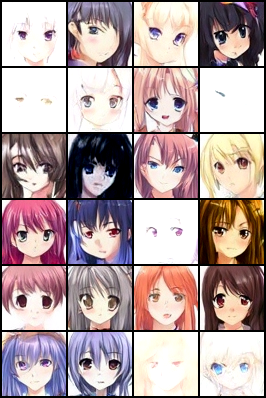

In [23]:
from PIL import Image
import glob

latest = sorted(glob.glob('samples/ddpm/epoch_*.png'))[-1]
print(latest)
Image.open(latest)


## 8. Evaluate the DDPM

DDPM ancestral sampling is inherently slow (1000 sequential steps per batch) - this will take noticeably longer than the VAE eval. Reduce `--num_samples` if you're short on quota.

In [34]:
!python eval_ddpm.py --num_samples 100

[checkpoint] loaded <- /content/checkpoints/ddpm.pt
Loaded DDPM (EMA weights) from /content/checkpoints/ddpm.pt
sampling: 100% 1000/1000 [01:05<00:00, 15.35it/s]
Saved preview grid to /content/samples/ddpm_eval/preview_grid.png
sampling: 100% 1000/1000 [04:09<00:00,  4.01it/s]
generated 64/100
sampling: 100% 1000/1000 [02:37<00:00,  6.34it/s]
generated 100/100
Saved 100 generated images to /content/samples/ddpm_eval


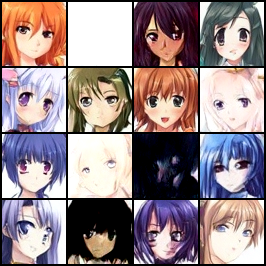

In [35]:
from PIL import Image
Image.open('samples/ddpm_eval/preview_grid.png')


## 9. Benchmark: FID + Inception Score

Scores both models' generated images against the real held-out test split.

In [37]:
from PIL import Image
import glob

files = glob.glob("/content/samples/vae_eval/*")
sizes = set(Image.open(f).size for f in files)
modes = set(Image.open(f).mode for f in files)

print("Image sizes found:", sizes)
print("Image modes found:", modes)

Image sizes found: {(64, 64)}
Image modes found: {'RGB'}


In [38]:
!python benchmark.py --both


=== Benchmarking 'VAE' ===
real: /content/data/test/all
fake: /content/samples/vae_eval

Computing FID...
100% 30/30 [00:07<00:00,  4.17it/s]
100% 2/2 [00:00<00:00,  4.35it/s]
FID: 282.9319

Computing Inception Score...
/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Inception Score: loading+scoring: 100% 100/100 [00:00<00:00, 206.17it/s]
Inception Score: 2.5753 +/- 0.4748

Saved results to /content/logs/benchmark_results.json

=== Benchmarking 'DDPM' ===
real: /content/data/test/all
fake: /content/samples/ddpm_eval

Computing FID...
100% 30/30 [00:07<00:00,  4.24it/s]
100% 2/2 [00:00<00:00,  3.84it/s]
FID: 91.9749

Computing Inception Score...
Inception Score: loading+scoring: 100% 100/100 [00:00<00:00, 406.01it/s]
Inception Score: 2.1678 +/- 0.2954

Saved results to /content/logs/ben

Thank YOU

By Mina Nasser